In [1]:
import sys
import os
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt

#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/nikko/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [13]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------

star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

In [14]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [15]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [16]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.67%  P=0.80  R=0.82  F1=0.81
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.34%  P=0.88  R=0.88  F1=0.88
CatBoost trained.
  [Training] Acc=93.17%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=90.23%  P=0.87  R=0.88  F1=0.87
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.
  [Training] Acc=91.31%  P=0.91  R=0.91  F1=0

In [17]:

if os.path.exists('trained_models/stacking_clf_inedx.pkl'):
    stacking_clf = joblib.load('trained_models/stacking_clf_index.pkl')
    print("Stacking Classifier caricato da disco")
else:
    stacking_clf = sc.train_stacking(X_train, y_train, X_val, y_val, n_jobs=2)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(stacking_clf, 'trained_models/stacking_clf_index.pkl')
    print("Stacking Classifier trained and saved")

Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.79%  P=0.80  R=0.82  F1=0.81
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.43%  P=0.88  R=0.88  F1=0.88
CatBoost trained.
  [Training] Acc=93.17%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=90.23%  P=0.87  R=0.88  F1=0.87
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.
  [Training] Acc=91.31%  P=0.91  R=0.91  F1=0

In [18]:
if os.path.exists('trained_models/voting_clf_inedx.pkl'):
    voting_clf = joblib.load('trained_models/voting_clf_index.pkl')
    print("Voting Classifier caricato da disco")
else:
    voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
    os.makedirs('trained_models', exist_ok=True)
    joblib.dump(voting_clf, 'trained_models/voting_clf_index.pkl')
    print("Voting Classifier trained and saved")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000732 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.
  [Training] Acc=95.55%  P=0.96  R=0.96  F1=0.96
  [Validation] Acc=90.46%  P=0.88  R=0.88  F1=0.88
Voting Classifier trained and saved


In [19]:
import torch
from stellar_classification.models.network import SimpleNN

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

if os.path.exists('trained_models/nn_model_index.pth'):
    nn_model = SimpleNN(input_size, num_classes)
    nn_model.load_state_dict(torch.load('trained_models/nn_model_index.pth'))
    nn_model.eval()
    print("NN caricata da disco")
else:
    nn_model = sc.train_neural( 
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=input_size,
        num_classes=num_classes,
        num_epochs=10,
        lr=0.001
    )
    torch.save(nn_model.state_dict(), 'trained_models/nn_model_index.pth')
    print("NN trainata e salvata")

Epoch  1/10  loss=0.4913  val_acc=85.78%
Epoch  2/10  loss=0.4192  val_acc=84.53%
Epoch  3/10  loss=0.4010  val_acc=86.61%
Epoch  4/10  loss=0.3881  val_acc=86.67%
Epoch  5/10  loss=0.3784  val_acc=86.03%
Epoch  6/10  loss=0.3693  val_acc=87.35%
Epoch  7/10  loss=0.3624  val_acc=86.08%
Epoch  8/10  loss=0.3568  val_acc=87.62%
Epoch  9/10  loss=0.3525  val_acc=88.12%
Epoch 10/10  loss=0.3479  val_acc=88.44%
NN trainata e salvata


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)
    
nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)



Voting Classifier:
  Accuracy  : 90.78%
  Precision: 0.8802
  Recall   : 0.8849
  F1       : 0.8818
  Confusion Matrix:
[[10194   364   223]
 [  218  3114   216]
 [  270   392  3266]]

Stacking Classifier:
  Accuracy  : 90.30%
  Precision: 0.8745
  Recall   : 0.8754
  F1       : 0.8748
  Confusion Matrix:
[[10213   326   242]
 [  253  3006   289]
 [  305   356  3267]]

Neural Network:
  Accuracy  : 88.59%
  Precision: 0.8522
  Recall   : 0.8596
  F1       : 0.8558
  Confusion Matrix:
[[10009   359   413]
 [  248  2970   330]
 [  363   370  3195]]


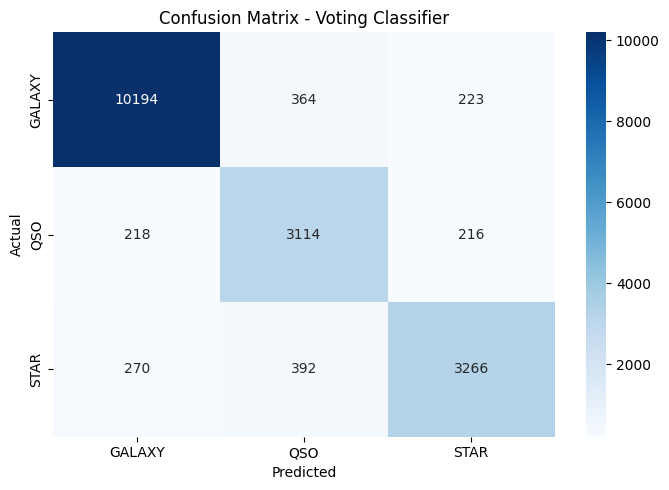

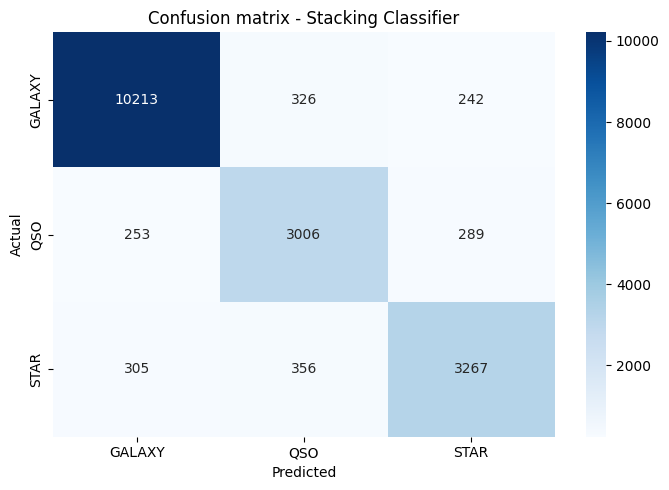

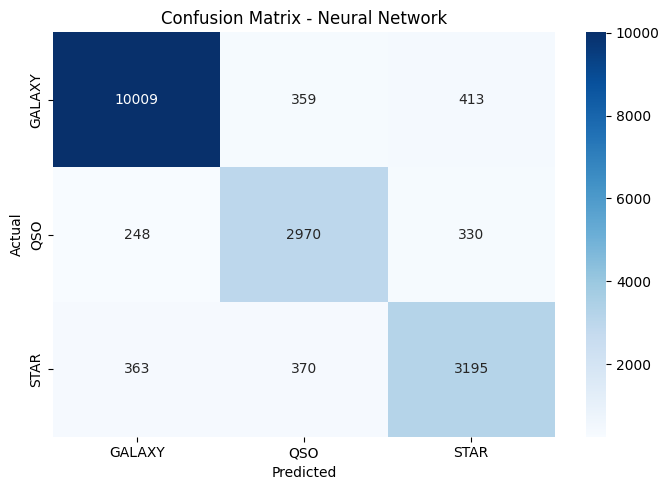

In [21]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.00515, 0.00375, 0.00275, 0.006  , 0.0027 , 0.00225, 0.0052 ,
       0.03275, 0.01125, 0.0972 , 0.0964 , 0.1589 , 0.0542 ]), array([0.00405, 0.007  , 0.0096 , 0.0093 , 0.0023 , 0.0035 , 0.00785,
       0.03835, 0.01605, 0.0997 , 0.08565, 0.1711 , 0.06275]), array([0.00375, 0.0049 , 0.00485, 0.01   , 0.00555, 0.00695, 0.00845,
       0.0398 , 0.0159 , 0.099  , 0.09005, 0.1603 , 0.05245]), array([0.00825, 0.00645, 0.008  , 0.00845, 0.00335, 0.00625, 0.00745,
       0.03415, 0.0168 , 0.09825, 0.08825, 0.16915, 0.0525 ]), array([ 0.00248117,  0.00389898,  0.00487373,  0.00877271, -0.00062029,
        0.00124058,  0.00301285,  0.0315463 ,  0.01417811,  0.10146212,
        0.08435977,  0.15666814,  0.05112982])]


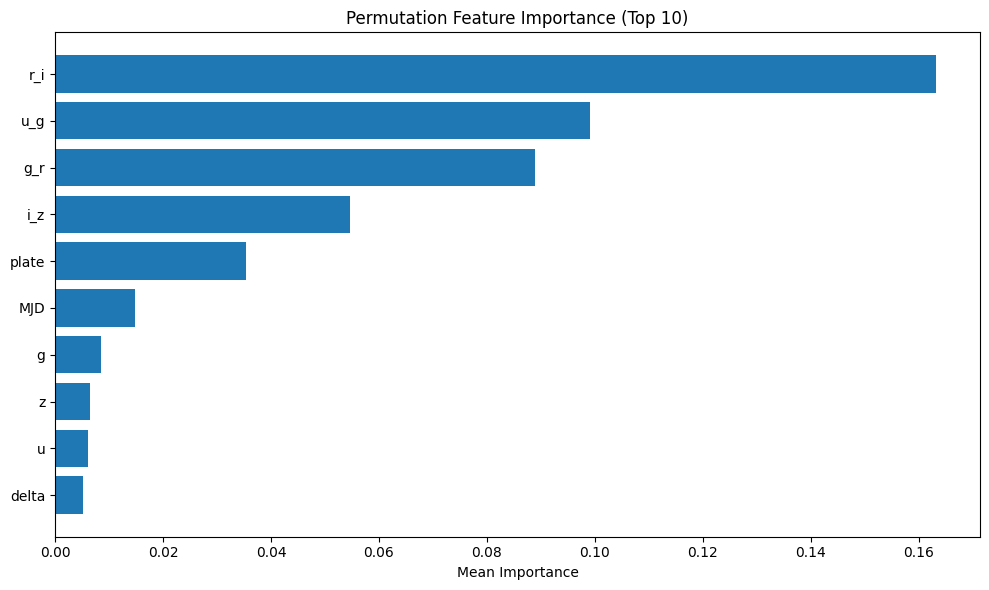

Feature Importance Scores:
r_i: 0.1632
u_g: 0.0991
g_r: 0.0889
i_z: 0.0546
plate: 0.0353
MJD: 0.0148
g: 0.0085
z: 0.0064
u: 0.0060
delta: 0.0052
alpha: 0.0047
i: 0.0040
r: 0.0027
1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257
[array([0.00585, 0.0052 , 0.0442 , 0.0247 , 0.00915, 0.01375, 0.02275,
       0.02905, 0.0344 , 0.1063 , 0.0868 , 0.2343 , 0.0739 ]), array([-5.0000e-05,  4.2000e-03,  4.1650e-02,  2.4450e-02,  8.7500e-03,
        1.3400e-02,  2.2250e-02,  3.4900e-02,  3.3350e-02,  1.0635e-01,
        8.1700e-02,  2.3120e-01,  8.3550e-02]), array([0.0029 , 0.00815, 0.0372 , 0.02495, 0.00955, 0.0208 , 0.0262 ,
       0.02965, 0.034  , 0.10665, 0.08   , 0.22295, 0.0775 ]), array([0.0011 , 0.00155, 0.0371 , 0.01985, 0.00815, 0.01145, 0.0193 ,
       0.02815, 0.02615, 0.1011 , 0.07565, 0.2307 , 0.07485]), array([0.00177226, 0.00460789, 0.03712893, 0.01931768, 0.00841825,
       0.01098804, 0.01736819, 0.02498892, 0.03003988, 0.10527

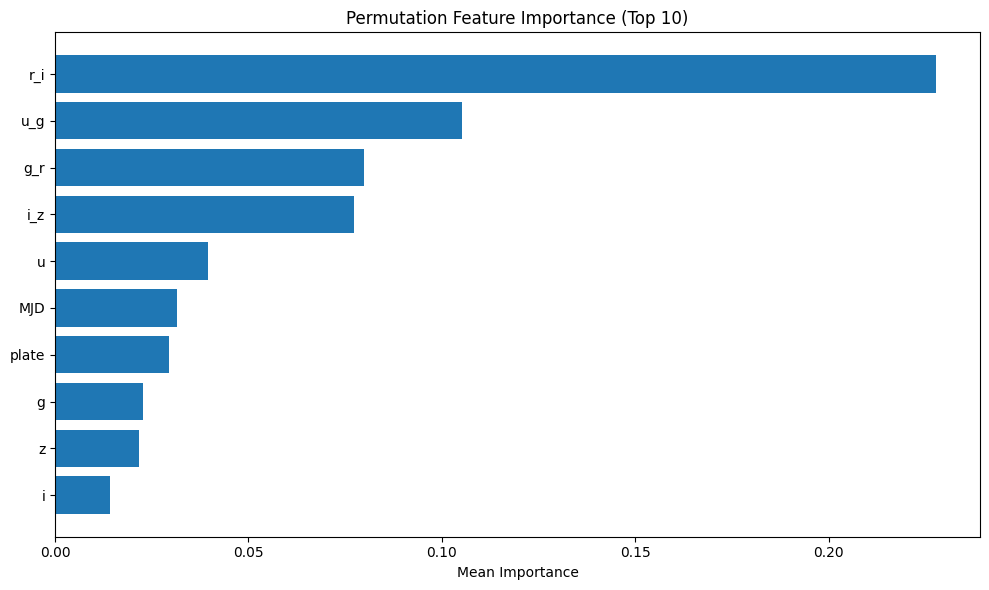

Feature Importance Scores:
r_i: 0.2277
u_g: 0.1051
g_r: 0.0798
i_z: 0.0772
u: 0.0395
MJD: 0.0316
plate: 0.0293
g: 0.0227
z: 0.0216
i: 0.0141
r: 0.0088
delta: 0.0047
alpha: 0.0023


In [22]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=6)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 

